In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

file_rotterdamPortData = r'..\data\rotterdam_dataset_16.xlsx'
wd = pd.read_excel(file_rotterdamPortData)
wd.info()
wd.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11076 entries, 0 to 11075
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Arrival_Date   11076 non-null  datetime64[ns]
 1   Vessel_ID      11076 non-null  object        
 2   Vessel_Type    11076 non-null  object        
 3   Cargo_tons     11076 non-null  int64         
 4   Berth_Time_hr  11076 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 432.8+ KB


,Arrival_Date,Vessel_ID,Vessel_Type,Cargo_tons,Berth_Time_hr
0,2022-01-01 23:51:00,V000001,Container,18379,17.2
1,2022-01-01 15:07:00,V000002,Container,22886,20.2
2,2022-01-01 08:29:00,V000003,Container,13054,19.3
3,2022-01-01 21:33:00,V000004,Tanker,40882,35.7
4,2022-01-01 09:07:00,V000005,Bulk,45645,27.2


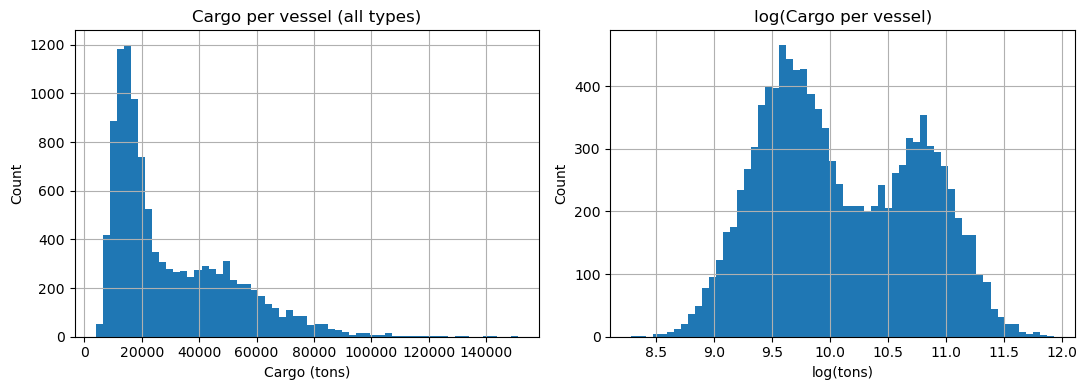

In [2]:
# distributional shape of cargo per vessel (all vessels together)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

wd['Cargo_tons'].hist(bins=60, ax=ax[0])
ax[0].set_title('Cargo per vessel (all types)')
ax[0].set_xlabel('Cargo (tons)')
ax[0].set_ylabel('Count')

np.log(wd['Cargo_tons']).hist(bins=60, ax=ax[1])
ax[1].set_title('log(Cargo per vessel)')
ax[1].set_xlabel('log(tons)')
ax[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

# the overall histogram is a mix of three vessel types, so we analyze each type separately

In [3]:
# descriptive stats/skewness per vessel type
types = ['Container', 'Tanker', 'Bulk']

stats_table = wd.groupby('Vessel_Type')['Cargo_tons'].agg(['count', 'mean', 'median', 'std', 'min', 'max', 'skew'])
stats_table['kurt'] = wd.groupby('Vessel_Type')['Cargo_tons'].apply(lambda x: x.kurt())
stats_table['CV'] = stats_table['std'] / stats_table['mean']
print(stats_table.round(2))

# skewness of log(cargo): close to 0 implies log(cargo) is symmetric (supporting lognormal)
wd['log_cargo'] = np.log(wd['Cargo_tons'])
print(wd.groupby('Vessel_Type')['log_cargo'].agg(['mean', 'std', 'skew']).round(3))

# all three types are right skewed (skew > 0, mean > median)

             count      mean   median       std    min     max  skew  kurt  \
Vessel_Type                                                                  
Bulk          2515  39001.64  37188.0  15399.09   6280  108873  0.79  0.82   
Container     6117  15801.23  14925.0   5691.87   3991   58186  1.16  2.74   
Tanker        2444  57284.20  54638.5  17358.64  17317  151271  1.02  1.87   

               CV  
Vessel_Type        
Bulk         0.39  
Container    0.36  
Tanker       0.30  
               mean    std   skew
Vessel_Type                      
Bulk         10.492  0.410 -0.409
Container     9.607  0.350 -0.023
Tanker       10.912  0.294  0.033


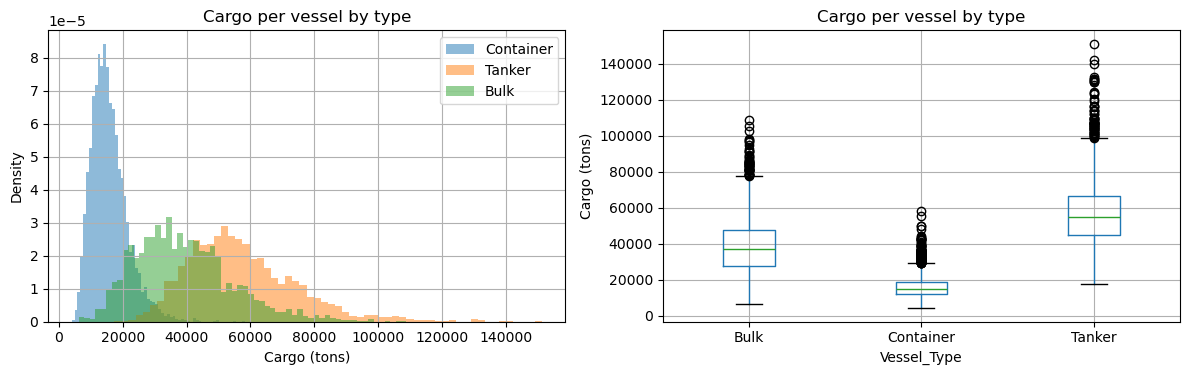

KruskalResult(statistic=7698.439284751777, pvalue=0.0)


In [4]:
# differences between vessel categories
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

for t in types:
    wd.loc[wd['Vessel_Type'] == t, 'Cargo_tons'].hist(bins=60, density=True, alpha=0.5, ax=ax[0], label=t)
ax[0].set_title('Cargo per vessel by type')
ax[0].set_xlabel('Cargo (tons)')
ax[0].set_ylabel('Density')
ax[0].legend()

wd.boxplot(column='Cargo_tons', by='Vessel_Type', ax=ax[1])
ax[1].set_title('Cargo per vessel by type')
ax[1].set_ylabel('Cargo (tons)')
plt.suptitle('')
plt.tight_layout()
plt.show()

# test whether the cargo distributions differ between types (Kruskal-Wallis, no normality needed)
groups = [wd.loc[wd['Vessel_Type'] == t, 'Cargo_tons'] for t in types]
print(stats.kruskal(*groups))

In [5]:
# fit candidate distributions per vessel type
# candidates are lognormal, gamma, weibull, normal (for the sake of a reference)
# parameters estimated by maximum likelihood (stats.fit), location fixed at 0 for the positive distributions for my readability

candidates = {'Lognormal': stats.lognorm,
              'Gamma': stats.gamma,
              'Weibull': stats.weibull_min,
              'Normal': stats.norm}
fits = {}
rows = []
for t in types:
    x = wd.loc[wd['Vessel_Type'] == t, 'Cargo_tons'].values
    for name in candidates:
        dist = candidates[name]
        if name == 'Normal':
            params = dist.fit(x)
            k = 2
        else:
            params = dist.fit(x, floc=0)
            k = 2   # loc is fixed, so only 2 free parameters
        fits[(t, name)] = params

        logL = np.sum(dist.logpdf(x, *params))
        aic = 2 * k - 2 * logL
        ks = stats.kstest(x, dist.cdf, args=params)
        rows.append([t, name, logL, aic, ks.statistic, ks.pvalue])

fit_table = pd.DataFrame(rows, columns=['Type', 'Distribution', 'logL', 'AIC', 'KS stat', 'KS p-value'])
print(fit_table.round(4).to_string(index=False))

# lower aic = better fit 
# ks p-value > 0.05 implies no evidence against the distribution 

     Type Distribution        logL         AIC  KS stat  KS p-value
Container    Lognormal -61020.0930 122044.1859   0.0090      0.6950
Container        Gamma -61074.8964 122153.7927   0.0257      0.0006
Container      Weibull -61511.3187 123026.6374   0.0605      0.0000
Container       Normal -61571.5882 123147.1765   0.0707      0.0000
   Tanker    Lognormal -27146.5693  54297.1387   0.0128      0.8160
   Tanker        Gamma -27169.1719  54342.3439   0.0315      0.0153
   Tanker      Weibull -27366.9354  54737.8709   0.0717      0.0000
   Tanker       Normal -27325.3364  54654.6728   0.0706      0.0000
     Bulk    Lognormal -27712.8720  55429.7441   0.0332      0.0077
     Bulk        Gamma -27679.9128  55363.8256   0.0177      0.4069
     Bulk      Weibull -27755.6987  55515.3973   0.0426      0.0002
     Bulk       Normal -27817.9198  55639.8395   0.0536      0.0000


In [6]:
# method of moments for the lognormal (I need this for the the basic scenario in 4.6)
# if X ~ Lognormal(mu, sigma^2):  E[X] = exp(mu + sigma^2/2),  Var[X] = (exp(sigma^2) - 1) exp(2mu + sigma^2)
# => sigma^2 = log(1 + s^2/m^2),  mu = log(m) - sigma^2/2
#I just have the calculation here for the ease of not having to look down at my nb over and over

rows = []
for t in types:
    x = wd.loc[wd['Vessel_Type'] == t, 'Cargo_tons'].values
    m = np.mean(x)
    s2 = np.var(x)
    sigma2 = np.log(1 + s2 / m**2)
    mu = np.log(m) - sigma2 / 2
    sigma = np.sqrt(sigma2)

    # lognorm(s=sigma, scale=exp(mu))
    ks = stats.kstest(x, stats.lognorm(s=sigma, scale=np.exp(mu)).cdf)
    rows.append([t, mu, sigma, ks.pvalue])

mom_table = pd.DataFrame(rows, columns=['Type', 'mu (MoM)', 'sigma (MoM)', 'KS p-value'])
print(mom_table.round(4).to_string(index=False))

     Type  mu (MoM)  sigma (MoM)  KS p-value
Container    9.6069       0.3493      0.7200
   Tanker   10.9119       0.2963      0.7890
     Bulk   10.4989       0.3806      0.0064


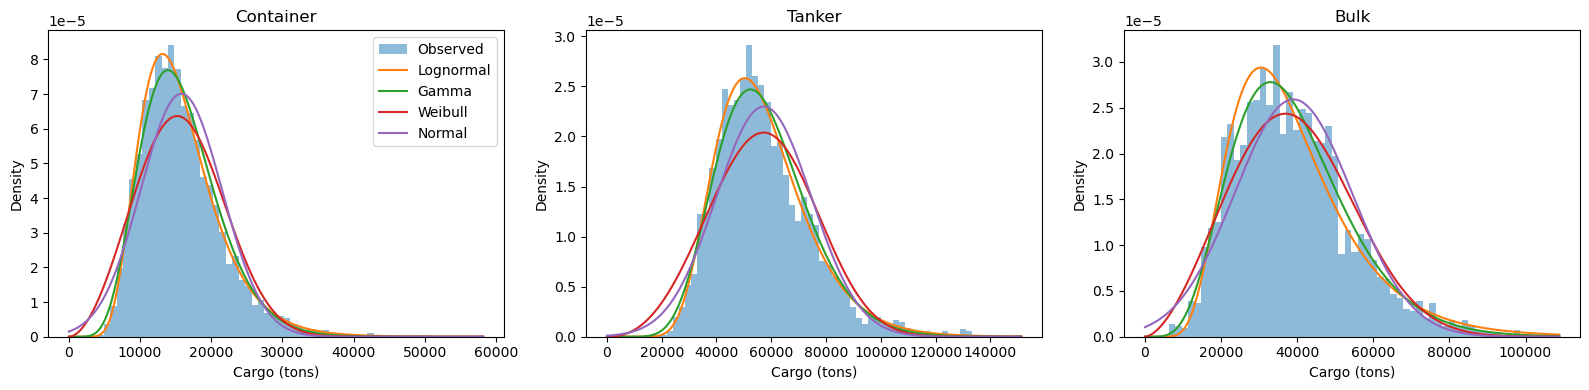

In [7]:
# histogram with fitted densities per vessel type
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

for i, t in enumerate(types):
    x = wd.loc[wd['Vessel_Type'] == t, 'Cargo_tons'].values
    ax[i].hist(x, bins=60, density=True, alpha=0.5, label='Observed')
    xs = np.linspace(0, x.max(), 500)
    for name in candidates:
        ax[i].plot(xs, candidates[name].pdf(xs, *fits[(t, name)]), lw=1.5, label=name)
    ax[i].set_title(t)
    ax[i].set_xlabel('Cargo (tons)')
    ax[i].set_ylabel('Density')
ax[0].legend()
plt.tight_layout()
plt.show()

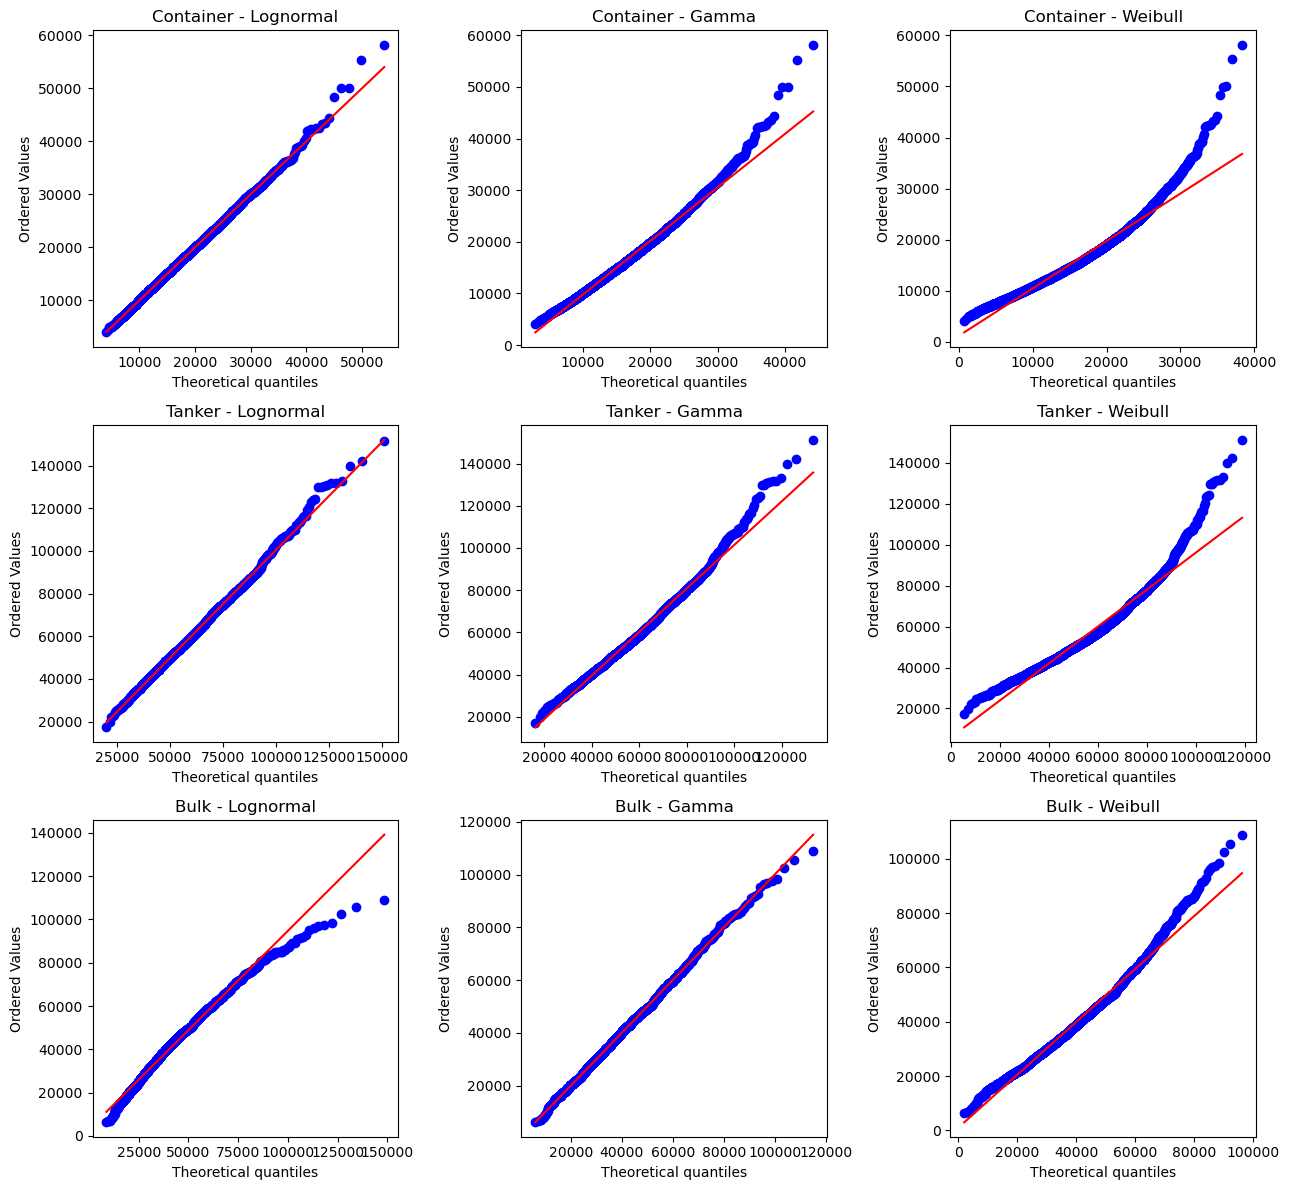

In [8]:
# QQ-plots: best way to see how well the tails are fitted (I remember this from FDA)
fig, ax = plt.subplots(3, 3, figsize=(13, 12))

for i, t in enumerate(types):
    x = wd.loc[wd['Vessel_Type'] == t, 'Cargo_tons'].values
    for j, name in enumerate(['Lognormal', 'Gamma', 'Weibull']):
        stats.probplot(x, dist=candidates[name](*fits[(t, name)]), plot=ax[i, j])
        ax[i, j].set_title(t + ' - ' + name)
plt.tight_layout()
plt.show()

In [9]:
# extreme observations
# outliers based on the IQR rule on log scale (because of the skewness)
for t in types:
    x = wd.loc[wd['Vessel_Type'] == t, 'Cargo_tons']
    lx = np.log(x)
    q1, q3 = np.percentile(lx, [25, 75])
    iqr = q3 - q1
    n_out = np.sum((lx < q1 - 1.5 * iqr) | (lx > q3 + 1.5 * iqr))
    print(t, '- outliers (log-IQR rule):', n_out, 'of', len(x))

# largest vessels per type
print(wd.sort_values('Cargo_tons', ascending=False).groupby('Vessel_Type').head(3)[['Vessel_ID', 'Vessel_Type', 'Cargo_tons', 'Berth_Time_hr']])

Container - outliers (log-IQR rule): 46 of 6117
Tanker - outliers (log-IQR rule): 21 of 2444
Bulk - outliers (log-IQR rule): 23 of 2515
      Vessel_ID Vessel_Type  Cargo_tons  Berth_Time_hr
4123    V004124      Tanker      151271           39.0
2805    V002806      Tanker      142320           34.2
4677    V004678      Tanker      139774           35.4
778     V000779        Bulk      108873           31.7
8374    V008375        Bulk      105530           27.9
7009    V007010        Bulk      102631           26.0
10672   V010673   Container       58186           20.6
7833    V007834   Container       55291           18.0
7988    V007989   Container       50003           17.8


In [10]:
# How important are the extremes?
# 1) share of the total cargo carried by the largest 1% of vessels
# 2) effect on the mean when removing the top 1%
# 3) compare observed tail probabilities with the fitted distributions

rows = []
for t in types:
    x = np.sort(wd.loc[wd['Vessel_Type'] == t, 'Cargo_tons'].values)
    q99 = np.percentile(x, 99)
    top = x[x > q99]
    share_top = np.sum(top) / np.sum(x)
    mean_without = np.mean(x[x <= q99])

    p_emp = np.mean(x > q99)
    p_logn = 1 - stats.lognorm.cdf(q99, *fits[(t, 'Lognormal')])
    p_gamma = 1 - stats.gamma.cdf(q99, *fits[(t, 'Gamma')])
    p_weib = 1 - stats.weibull_min.cdf(q99, *fits[(t, 'Weibull')])
    rows.append([t, q99, share_top, np.mean(x), mean_without, p_emp, p_logn, p_gamma, p_weib])

ext_table = pd.DataFrame(rows, columns=['Type', '99% quantile', 'Share top 1%', 'Mean', 'Mean w/o top 1%',
                                        'P(X>q99) data', 'Lognormal', 'Gamma', 'Weibull'])
print(ext_table.round(4).to_string(index=False))

     Type  99% quantile  Share top 1%       Mean  Mean w/o top 1%  P(X>q99) data  Lognormal  Gamma  Weibull
Container      33344.16        0.0245 15801.2297       15571.7815         0.0101     0.0105 0.0051   0.0022
   Tanker     109692.32        0.0221 57284.2009       56596.2679         0.0102     0.0092 0.0049   0.0020
     Bulk      84190.06        0.0242 39001.6386       38454.9928         0.0103     0.0192 0.0092   0.0032


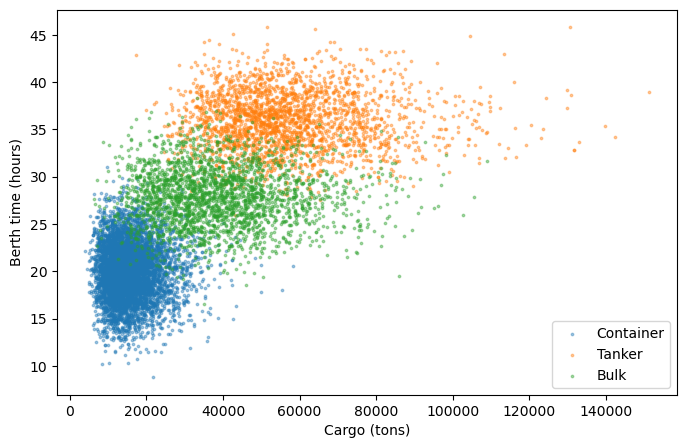

                           Cargo_tons  Berth_Time_hr
Vessel_Type                                         
Bulk        Cargo_tons          1.000         -0.017
            Berth_Time_hr      -0.017          1.000
Container   Cargo_tons          1.000          0.001
            Berth_Time_hr       0.001          1.000
Tanker      Cargo_tons          1.000         -0.008
            Berth_Time_hr      -0.008          1.000


In [11]:
# relation between cargo and berth time (useful for interpreting extremes operationally)
fig, ax = plt.subplots(figsize=(8, 5))
for t in types:
    sub = wd[wd['Vessel_Type'] == t]
    ax.scatter(sub['Cargo_tons'], sub['Berth_Time_hr'], s=3, alpha=0.4, label=t)
ax.set_xlabel('Cargo (tons)')
ax.set_ylabel('Berth time (hours)')
ax.legend()
plt.show()

print(wd.groupby('Vessel_Type')[['Cargo_tons', 'Berth_Time_hr']].corr().round(3))